# `splitting` — undoing merged `sensor` clusters

A `sensor` cluster is just a connected component of hit pixels — when
`multi.n_particles > 1` with a wide opening angle (as in `configs/p123.yaml`),
more than one truth particle's charge routinely lands in the same connected
component. `splitting` decides how to split such a cluster back apart into
per-particle sub-clusters, behind a pluggable `Splitter` interface so future
(non-truth) algorithms can be dropped in and compared.

This notebook uses the one splitter that ships today, `TruthSplitter` — an
**oracle** that looks at the ground-truth `contributions` table (which
particle deposited how much charge into which pixel) and assigns each pixel
to its dominant contributor. It can't run on real data (no `contributions`
table exists there), but it's the reference other splitters get validated
against.


In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

from sensor.sim import load_config as load_sensor_config
from sensor.cli import run_simulation
from sensor.analysis import cluster_purity
from sensor.vis import plot_event

from splitting import Splitter, apply_splitter, TruthSplitter


## A run with routinely-merged clusters

`configs/p123.yaml` draws 1-3 particles per event (uniform), all sharing one
vertex with a wide (0.5 rad) opening angle — exactly the regime where
clusters merge.


In [2]:
config = load_sensor_config("../aihep/clustering/sensor/configs/p123.yaml")
config.n_events = 300
config.seed = 123

hits, clusters, truth, contributions = run_simulation(config)
print(f"{len(hits)} hit pixels, {len(clusters)} clusters, {len(truth)} truth particles")


17643 hit pixels, 16299 clusters, 617 truth particles


## Purity before splitting

`cluster_purity` traces each cluster back to every truth particle that
contributed charge to it. The *dominant* contributor's own fraction — how
much of the cluster's charge is genuinely "theirs" — is well below 1 for a
merged cluster.


In [3]:
purity_before = cluster_purity(hits, contributions)
dominant_before = purity_before.groupby(["event_id", "cluster_id"])["fraction"].max()
print(f"mean dominant-particle charge fraction, before split: {dominant_before.mean():.2f}")


mean dominant-particle charge fraction, before split: 0.61


## Applying `TruthSplitter`

`apply_splitter(splitter, hits, clusters, contributions)` is the shared
machinery every splitter reuses: it turns a per-pixel label (from the
splitter's own `split_key`) into a fully self-consistent `(hits, clusters)`
pair — renumbering `cluster_id` densely per event and recomputing every
cluster aggregate (pixel count, charge sum, both centroids, spans).
`truth`/`contributions` pass through unchanged; splitting never touches
ground truth.


In [4]:
splitter = TruthSplitter()
split_hits, split_clusters = apply_splitter(splitter, hits, clusters, contributions)
print(f"{len(clusters)} clusters before split -> {len(split_clusters)} after")

purity_after = cluster_purity(split_hits, contributions)
dominant_after = purity_after.groupby(["event_id", "cluster_id"])["fraction"].max()
print(f"mean dominant-particle charge fraction, after split: {dominant_after.mean():.2f}")


16299 clusters before split -> 16614 after
mean dominant-particle charge fraction, after split: 0.85


The purity improves substantially but **doesn't reach 1.0, even for an
oracle**: when multiple particles share a vertex, their charge-collection
paths genuinely overlap in individual pixels near it. A splitter can pick
the dominant owner per pixel, but it can't subdivide a single pixel — some
residual cross-particle contamination is a hard floor of any pixel-grained
splitter, truth-based or not.


## Before vs. after, on one merged cluster

Pick one of the clusters whose dominant-particle fraction was well below 1
before splitting, and compare the same event's display before/after —
`split_hits`/`split_clusters` have exactly `sensor`'s own schema, so
`sensor.vis.plot_event` works on either unchanged.


event 0, cluster 43: dominant fraction was 0.35


Text(0.5, 0.98, 'Before splitting')

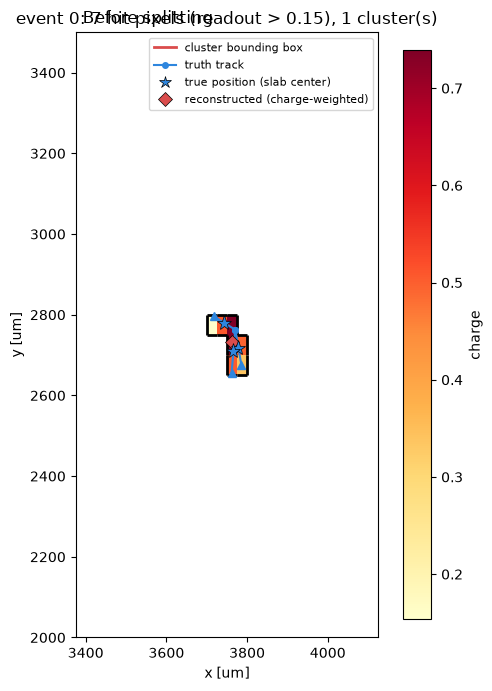

In [5]:
merged = dominant_before[dominant_before < 0.7]
event_id, cluster_id = merged.index[0]
print(f"event {event_id}, cluster {cluster_id}: dominant fraction was {merged.iloc[0]:.2f}")

fig = plot_event(hits, clusters, truth, config.detector, event_id=event_id, zoom=(30, 30))
fig.suptitle("Before splitting")


Text(0.5, 0.98, 'After TruthSplitter')

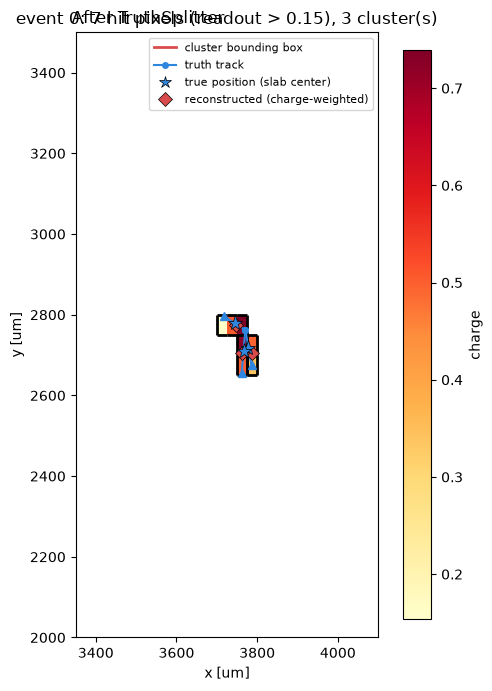

In [6]:
fig = plot_event(split_hits, split_clusters, truth, config.detector, event_id=event_id, zoom=(30, 30))
fig.suptitle("After TruthSplitter")


## Writing a custom splitter

Every splitting algorithm is just a `Splitter` subclass implementing
`split_key(hits, clusters, contributions) -> pd.Series` — one label per row
of `hits`; pixels in the same original cluster that get the same label stay
together, different labels split them apart (labels are only ever compared
*within* one `(event_id, cluster_id)` group). `apply_splitter` handles all
the renumbering/aggregation regardless of algorithm — a new splitter is
*only* the per-pixel labeling decision.

Here's the trivial no-op splitter (every pixel gets the same label, so
nothing splits) as a minimal, runnable example of the interface:


In [7]:
class NoOpSplitter(Splitter):
    name = "no-op"

    def split_key(self, hits: pd.DataFrame, clusters: pd.DataFrame, contributions: pd.DataFrame) -> pd.Series:
        return pd.Series(0, index=hits.index)

noop_hits, noop_clusters = apply_splitter(NoOpSplitter(), hits, clusters, contributions)
assert len(noop_clusters) == len(clusters)
print("no-op splitter leaves cluster count unchanged:", len(noop_clusters), "==", len(clusters))


no-op splitter leaves cluster count unchanged: 16299 == 16299
